# Analyses v2.2

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.spc as spc
import analyses.linreg as linreg
import analyses.pfr as pfr
import analyses.mwr as mwr 
import analyses.r1_intrusion as r1_intrusion
import analyses.rt_init as rt_init
import analyses.pli_eli as pli_eli
import analyses.irt as irt 
import analyses.tcl as tcl
import analyses.lcrp as lcrp
import analyses.scl as scl
import analyses.statistics as stat_tests
from scipy.stats import wilcoxon
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

## 0. Load and Clean

In [76]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfru_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfru_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data\data_storage\dirfru_trials_20260925_101012.csv


In [77]:
# Manual Exclusion
exclude_pid = []
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 389801 rows
After exclusion: 389801 rows
Excluded data (Prolific IDs: [])


In [78]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.int64, numpy.float64)

In [79]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 4150 recall(s).


In [80]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 6109b252880d6d711a5645b4 in session 1 had a recall proportion of 0.96, which is above the threshold.
Participant 69eb5d9fbfddb861d43a0d0f in session 0 took notes.
Participant 69eb5d9fbfddb861d43a0d0f in session 1 took notes.
Participant 69eb5d9fbfddb861d43a0d0f in session 4 took notes.
Participant 6a178e2e2b82ec7429f2353c in session 3 had 2 trials with zero correct recalls.
Participant 6aaad41d8d7a5723ab6e9ce7 in session 0 had a recall proportion of 0.96, which is above the threshold.
Participant stel01 in session 3 had 2 trials with zero correct recalls.
Excluded sessions by quality criteria: 7


,prolific_pid,session
673,6109b252880d6d711a5645b4,1
62,69eb5d9fbfddb861d43a0d0f,0
138,69eb5d9fbfddb861d43a0d0f,1
206,69eb5d9fbfddb861d43a0d0f,4
506,6a178e2e2b82ec7429f2353c,3
734,6aaad41d8d7a5723ab6e9ce7,0
4,stel01,3


## 1. Inspection

In [81]:
df = df[df['study_id'] != 'test']
study_ids = df['study_id'].unique()
print(f"Unique study IDs in the dataset: {study_ids}")

Unique study IDs in the dataset: <StringArray>
['6a2767189a4f0e0a29dc9a32', '6a27672e9f42f5fc0f800c49',
 '6a2768acf487b7842842f74c', '6a276962874a96d003489c45',
 '6a2769b25cbe191d4bf90bba', '6a94e3286f8fd3491209112a',
 '6a94e406a70405ad5a421026', '6a94e5555b00e0e80a3ac706',
 '6a94e598703277b3ace1b216', '6a94e5d410e6c6c4deca61c7']
Length: 10, dtype: str


In [82]:
# temporary code-checking selection

df = df[df['study_id'].isin(['6a94e3286f8fd3491209112a', '6a94e406a70405ad5a421026', '6a94e5555b00e0e80a3ac706', 
                             '6a94e598703277b3ace1b216', '6a94e5d410e6c6c4deca61c7'])]

In [83]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])

# Exclude session 0 before counting toward "included sessions"
included_sessions = session_info[session_info['session'] != 0]

# Count included sessions per participant, keep those with 2+
session_counts = included_sessions.groupby('prolific_pid')['session'].nunique()
twoplus_pids = session_counts[session_counts >= 2].index

# Get one condition label per participant (assumes condition is fixed per participant)
pid_condition = session_info.drop_duplicates('prolific_pid').set_index('prolific_pid')['initiation_condition']

twoplus_conditions = pid_condition.loc[twoplus_pids]

print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ sessions: {len(twoplus_pids)}')
print(f"Condition breakdown for participants with 2+ sessions: {twoplus_conditions.value_counts().to_dict()}")

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

231932 rows across 194 participants, 668 sessions
Condition breakdown by session: {'primacy': 243, 'recency': 228, 'free': 197}
Participants with 2+ sessions: 124
Condition breakdown for participants with 2+ sessions: {'recency': 43, 'primacy': 42, 'free': 39}
Total Sessions Completed: 5
Session 0    193
Session 1    160
Session 2    125
Session 3    112
Session 4     78
Name: count, dtype: int64


In [94]:
# Per-Subject Inspection
pid = '69e2b2d707a51a46285ebc85' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mean_words = mwr.mwr_sess(data)
    print(f"Session {i}: {mean_words}")

Condition per Session:
Session 0: primacy
Session 1: primacy
Session 2: primacy
Mean Words Recalled per Session:
Session 0: 11.0
Session 1: 12.666666666666666
Session 2: 15.416666666666666


In [102]:
# Per-List Inspection
pid = '61366a0250ad37452b08b9a3' # (replace with actual Prolific ID of interest)
session = 0
list_num = 0

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

Participant 61366a0250ad37452b08b9a3, Session 0, List 0
Initiation direction: free
Words recalled: 3


,serial_position,word_shown,recalled_word,recalled_serial_position,intrusion_type
row,,,,,
1,1.0,skillet,ankle,20,correct
2,2.0,sidewalk,muffin,19,correct
3,3.0,bank,skillet,1,correct
4,4.0,arm,(empty),no response,no response
5,5.0,maple,(empty),no response,no response
...,...,...,...,...,...
76,NaN,NaN,(empty),no response,no response
77,NaN,NaN,head,ELI,ELI
78,NaN,NaN,grass,ELI,ELI


## T-test for non-random attrition

In [32]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
p0_not_p1 = set(filtered_p0ids) - set(filtered_p1ids)
p0_not_p1_df = df[(df['prolific_pid'].isin(p0_not_p1)) & (df['session'] == 0)]
p0_with_p1_df = df[(df['prolific_pid'].isin(filtered_p1ids)) & (df['session'] == 0)]

In [12]:
mwr_p0notp1 = mwr.mwr(p0_not_p1_df)
mwr_p1plus = mwr.mwr(p0_with_p1_df)

In [76]:
from scipy import stats

mwr_0 = mwr_p0notp1['mwr'].dropna()
mwr_1 = mwr_p1plus['mwr'].dropna()

print(f"n (p0 not p1) = {len(mwr_0)}")
print(f"mean (p0 not p1) = {mwr_0.mean():.3f}")
print(f"n (p1 plus) = {len(mwr_1)}")
print(f"mean (p1 plus) = {mwr_1.mean():.3f}")

t_stat, p_value = stats.ttest_ind(mwr_0, mwr_1, equal_var=False, nan_policy='omit')
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

NameError: name 'mwr_p0notp1' is not defined

## 2. Demographics


In [203]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [204]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_df['initiation_condition'] = age_df['prolific_pid'].map(pid_condition)

age_stats = age_df.groupby('initiation_condition')['age'].describe()
age_stats 

,count,mean,std,min,25%,50%,75%,max
initiation_condition,,,,,,,,
free,54.0,26.000000,2.781339,20.0,24.0,26.0,28.75,30.0
primacy,72.0,25.597222,3.539156,19.0,23.0,26.0,28.00,30.0
recency,62.0,25.532258,2.826791,20.0,23.0,25.0,27.75,30.0


In [205]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
104220,671e4b927fa293418ae656d8,1,Female
104461,5e4adda1fb8d9f03ca4c30f7,1,Female
104723,69bae2c1966ff851ff944610,0,Male
104950,69e83573abc974c1c5bac48b,0,Male
105180,6a178e2e2b82ec7429f2353c,0,Male


In [206]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,initiation_condition,gender
0,5a8895f0f1408d0001769b7b,28.0,free,Female
1,5afeea460437f000017e0c97,26.0,primacy,Male
2,5c8ec49f692c610001e14eca,28.0,primacy,Male
3,5cc8a32f7639bd0001ccce85,29.0,recency,Female
4,5d22686d9b3bf900019d73c0,28.0,free,Male


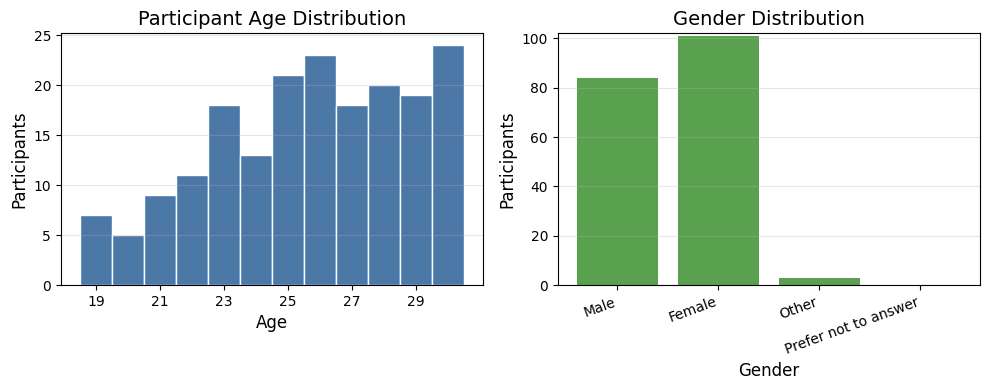

In [207]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Correct Filtering (FINAL ALGO)

In [208]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
filtered_p2ids = df[df['session'] == 2]['prolific_pid'].unique()
filtered_participants = set(filtered_p0ids) & set(filtered_p1ids) & set(filtered_p2ids)
filtered_df = df[(df['prolific_pid'].isin(filtered_participants)) & (df['session'] >= 1)]
print(filtered_df[filtered_df['session'] == 1]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 2]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 3]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 4]['prolific_pid'].nunique())

112
112
91
56


In [209]:
sessions_1_to_4 = df[df['session'].between(1, 4)]

session_condition_info = sessions_1_to_4[
    sessions_1_to_4['prolific_pid'].isin(filtered_participants)
][['prolific_pid', 'session', 'initiation_condition']].drop_duplicates()

condition_session_counts = (
    session_condition_info
    .groupby(['prolific_pid', 'initiation_condition'], as_index=False)['session']
    .nunique()
)

matching_participant_conditions = condition_session_counts[
    condition_session_counts['session'] >= 2
][['prolific_pid', 'initiation_condition']]

filtered_df_2 = sessions_1_to_4.merge(
    matching_participant_conditions,
    on=['prolific_pid', 'initiation_condition'],
    how='inner',
)

print(f"Participants included: {filtered_df_2['prolific_pid'].nunique()}")
print(f"Sessions included: {filtered_df_2[['prolific_pid', 'session']].drop_duplicates().shape[0]}")
print(
    filtered_df_2[['prolific_pid', 'session', 'initiation_condition']]
    .drop_duplicates()
    .groupby('initiation_condition')['prolific_pid']
    .nunique()
)


Participants included: 112
Sessions included: 371
initiation_condition
free       34
primacy    39
recency    39
Name: prolific_pid, dtype: int64


In [210]:
df_temp = filtered_df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
primacy    39
recency    39
free       34
Name: count, dtype: int64


In [211]:
primacy_df = filtered_df[filtered_df['initiation_condition'] == 'primacy']
primacy_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
primacy_age = primacy_df[['prolific_pid']].drop_duplicates().merge(primacy_age_df, on='prolific_pid', how='left')['age']
primacy_age.describe()

count    39.000000
mean     26.000000
std       3.178878
min      19.000000
25%      25.000000
50%      26.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [212]:
recency_df = filtered_df[filtered_df['initiation_condition'] == 'recency']
recency_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
recency_age = recency_df[['prolific_pid']].drop_duplicates().merge(recency_age_df, on='prolific_pid', how='left')['age']
recency_age.describe()

count    39.000000
mean     25.948718
std       3.060347
min      20.000000
25%      23.500000
50%      26.000000
75%      29.000000
max      30.000000
Name: age, dtype: float64

In [213]:
free_df = filtered_df[filtered_df['initiation_condition'] == 'free']
free_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
free_age = free_df[['prolific_pid']].drop_duplicates().merge(free_age_df, on='prolific_pid', how='left')['age']
free_age.describe()

count    34.000000
mean     25.941176
std       2.707354
min      21.000000
25%      24.000000
50%      26.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

## F7(a-b). Serial Position Curve (SPC)

In [214]:
spc_df = spc.spc_df(filtered_df)
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
spc_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5afeea460437f000017e0c97,1,primacy,1.000000,0.916667,0.500000,0.500000,0.250000,0.333333,0.250000,...,0.166667,0.083333,0.166667,0.166667,0.250000,0.166667,0.333333,0.583333,0.666667,0.750000
1,5afeea460437f000017e0c97,2,primacy,0.750000,1.000000,0.666667,0.166667,0.000000,0.250000,0.333333,...,0.166667,0.083333,0.166667,0.500000,0.333333,0.333333,0.416667,0.500000,0.416667,0.500000
2,5afeea460437f000017e0c97,3,primacy,1.000000,1.000000,0.916667,0.333333,0.083333,0.083333,0.000000,...,0.166667,0.333333,0.333333,0.166667,0.250000,0.333333,0.500000,0.500000,0.416667,0.833333
3,5afeea460437f000017e0c97,4,primacy,0.916667,0.833333,0.666667,0.666667,0.583333,0.083333,0.083333,...,0.583333,0.083333,0.250000,0.166667,0.500000,0.250000,0.250000,0.333333,0.583333,0.916667
4,5c8ec49f692c610001e14eca,1,primacy,1.000000,1.000000,1.000000,0.416667,0.166667,0.166667,0.083333,...,0.166667,0.000000,0.083333,0.250000,0.166667,0.166667,0.333333,0.416667,0.583333,1.000000


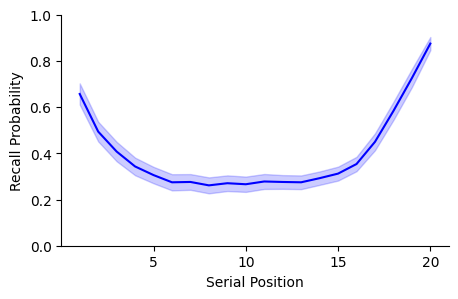

In [215]:
overall_spc = spc.spc_plot_overall(spc_df, path=f'figures/7a_spc_overall.pdf')

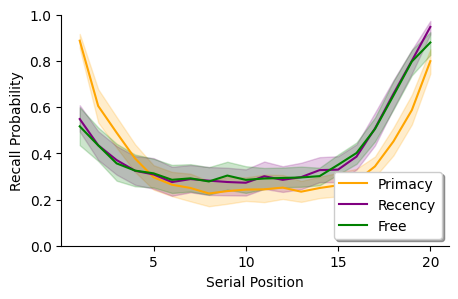

In [216]:
spc_bycond = spc.spc_plot(spc_df, path=f'figures/7b_spc_by_condition.pdf')

In [217]:
participant_curves = spc_df.groupby(['prolific_pid', 'initiation_condition'], as_index=False)[sp_cols].mean()

curves = participant_curves[sp_cols].to_numpy()

left_half = curves[:, :10]
right_half_reversed = curves[:, 10:][:, ::-1]

participant_curves['spc_asymmetry'] = (left_half - right_half_reversed).mean(axis=1)
stat_result = stat_tests.one_sample(participant_curves, ['spc_asymmetry'])
print(stat_result)

  initiation_condition        measure        test   n    t_stat         p_val  \
0              primacy  spc_asymmetry  one_sample  39  1.002995  3.222077e-01   
1              recency  spc_asymmetry  one_sample  39 -8.366669  3.787788e-10   
2                 free  spc_asymmetry  one_sample  34 -5.202655  1.014727e-05   

   dof   cohen_d    p_val_holm  
0   38  0.160608  3.222077e-01  
1   38 -1.339739  1.136336e-09  
2   33 -0.892248  2.029454e-05  


## F7(c): Linear Regression Gradient Trend

In [218]:
linreg_df = spc_df.apply(linreg.prim_rec_lr, axis=1)
linreg_df.head(5)

,prolific_pid,session,initiation_condition,prim_slope,prim_intercept,rec_slope,rec_intercept
0,5afeea460437f000017e0c97,1,primacy,-0.191667,1.208333,0.150000,0.050000
1,5afeea460437f000017e0c97,2,primacy,-0.233333,1.216667,0.033333,0.333333
2,5afeea460437f000017e0c97,3,primacy,-0.250000,1.416667,0.091667,0.241667
3,5afeea460437f000017e0c97,4,primacy,-0.083333,0.983333,0.166667,-0.033333
4,5c8ec49f692c610001e14eca,1,primacy,-0.225000,1.391667,0.191667,-0.075000


In [219]:
stat_tests.one_sample(linreg_df, ["prim_slope", "rec_slope"])

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,prim_slope,one_sample,39,-18.640898,1.028809e-20,38,-2.984933,6.172857e-20
1,primacy,rec_slope,one_sample,39,14.723290,2.762366e-17,38,2.357613,1.177028e-16
2,recency,prim_slope,one_sample,39,-6.467680,1.302529e-07,38,-1.035658,2.605059e-07
3,recency,rec_slope,one_sample,39,14.795938,2.354056e-17,38,2.369246,1.177028e-16
4,free,prim_slope,one_sample,34,-6.362638,3.331333e-07,33,-1.091183,3.331333e-07
5,free,rec_slope,one_sample,34,13.891009,2.429585e-15,33,2.382288,7.288756e-15


In [220]:
stat_tests.condition_contrast(linreg_df, ["prim_slope", "rec_slope"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prim_slope,welch,primacy vs free,39,34,34,-8.054918,1.498977e-11,69.614760,-1.890189,8.993860e-11
1,prim_slope,welch,recency vs free,39,34,34,-0.605417,5.468366e-01,70.846090,-0.140248,1.000000e+00
2,prim_slope,welch,primacy vs recency,39,39,39,-6.914722,1.459731e-09,73.467061,-1.565876,7.298657e-09
3,rec_slope,welch,primacy vs free,39,34,34,0.256706,7.981564e-01,70.247993,0.060082,1.000000e+00
4,rec_slope,welch,recency vs free,39,34,34,1.272112,2.074844e-01,70.995334,0.295791,8.299375e-01
5,rec_slope,welch,primacy vs recency,39,39,39,-1.043156,3.002126e-01,75.321261,-0.236228,9.006379e-01


In [221]:
linreg_df.groupby("prolific_pid")["initiation_condition"].nunique().value_counts()

initiation_condition
1    112
Name: count, dtype: int64

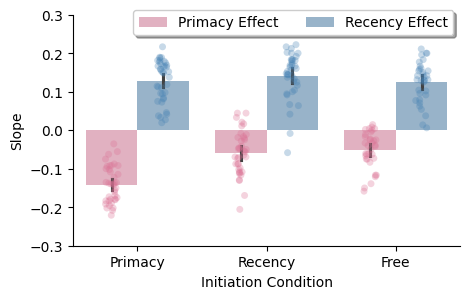

In [222]:
linreg_plot = linreg.plot_linreg(linreg_df, path=f'figures/7c_prim_rec_slopes.pdf')

## F7(d): PFR

In [223]:
pfr_df = pfr.pfr(filtered_df)
pfr_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5afeea460437f000017e0c97,1,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5afeea460437f000017e0c97,2,primacy,0.888889,0.0,0.111111,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5afeea460437f000017e0c97,3,primacy,0.916667,0.0,0.083333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5afeea460437f000017e0c97,4,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5c8ec49f692c610001e14eca,1,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


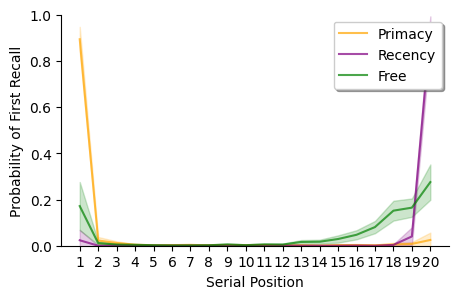

In [224]:
pfr.pfr_plot(pfr_df, path=f'figures/7d_pfr_by_condition.pdf')

In [1433]:
# average sessions within participant-condition first
participant_df = (
    pfr_df
    .groupby(["prolific_pid", "initiation_condition"], as_index=False)
    [[f"sp_{i}" for i in range(1, 21)]]
    .mean()
)

# create grouped serial-position bins
participant_df["SP 1-3"] = participant_df[[f"sp_{i}" for i in range(1, 4)]].sum(axis=1)
participant_df["SP 18-20"] = participant_df[[f"sp_{i}" for i in range(18, 21)]].sum(axis=1)

binned_percent = (
    participant_df
    .groupby("initiation_condition")[["SP 1-3", "SP 18-20"]]
    .mean()
    .reset_index()
)

binned_percent

,initiation_condition,SP 1-3,SP 18-20
0,free,0.099937,0.674369
1,primacy,0.956858,0.010088
2,recency,0.046561,0.951455


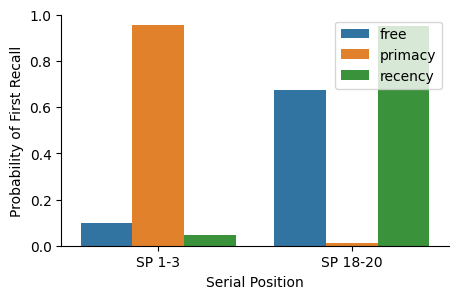

In [1434]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = binned_percent.melt(
    id_vars="initiation_condition",
    var_name="serial_position_bin",
    value_name="prob_first_recall"
)

plt.figure(figsize=(5, 3))

sns.barplot(
    data=plot_df,
    x="serial_position_bin",
    y="prob_first_recall",
    hue="initiation_condition",
)

plt.xlabel("Serial Position")
plt.ylabel("Probability of First Recall")
plt.ylim(0, 1)
plt.legend(loc='upper right')
sns.despine()
plt.show()


## F8(a-b): Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [225]:
mwr_df = mwr.mwr(filtered_df)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5afeea460437f000017e0c97,1,primacy,7.750000
1,5afeea460437f000017e0c97,2,primacy,6.833333
2,5afeea460437f000017e0c97,3,primacy,8.000000
3,5afeea460437f000017e0c97,4,primacy,8.250000
4,5c8ec49f692c610001e14eca,1,primacy,7.083333


In [226]:
# Mean words recalled, averaged within participant first, then across participants by condition
mwr_participant = stat_tests.participant_condition_mean(mwr_df, ["mwr"])

mwr_summary = (
    mwr_participant
    .groupby("initiation_condition")["mwr"]
    .agg(mean="mean", sd="std", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)), n="count")
)

mwr_summary

,mean,sd,sem,n
initiation_condition,,,,
free,8.155637,2.430679,0.416858,34
primacy,7.577991,2.412364,0.386287,39
recency,8.220085,2.896086,0.463745,39


In [227]:
mwr_df.groupby(["prolific_pid", "initiation_condition"])["mwr"].describe()

,,count,mean,std,min,25%,50%,75%,max
prolific_pid,initiation_condition,,,,,,,,
5afeea460437f000017e0c97,primacy,4.0,7.708333,0.618017,6.833333,7.520833,7.875000,8.062500,8.250000
5c8ec49f692c610001e14eca,primacy,4.0,7.229167,0.740292,6.250000,6.875000,7.375000,7.729167,7.916667
5cc8a32f7639bd0001ccce85,recency,3.0,4.333333,0.363242,3.916667,4.208333,4.500000,4.541667,4.583333
5d22686d9b3bf900019d73c0,free,3.0,5.250000,0.661438,4.500000,5.000000,5.500000,5.625000,5.750000
5d49fbb01da04c001a407042,free,2.0,11.833333,0.589256,11.416667,11.625000,11.833333,12.041667,12.250000
...,...,...,...,...,...,...,...,...,...
6a989bd720a255be4ad69ac8,primacy,3.0,5.000000,1.293681,3.666667,4.375000,5.083333,5.666667,6.250000
6a9a328fa9d5271e516ecd66,primacy,2.0,6.000000,0.117851,5.916667,5.958333,6.000000,6.041667,6.083333
6a9b19fbbdc9013925fdf8e4,primacy,3.0,5.694444,0.929207,5.000000,5.166667,5.333333,6.041667,6.750000


In [228]:
stat_tests.condition_contrast(mwr_df, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,39,34,34,-1.016408,0.312960,69.502127,-0.238608,0.872617
1,mwr,welch,recency vs free,39,34,34,0.103355,0.917973,70.908849,0.023960,0.917973
2,mwr,welch,primacy vs recency,39,39,39,-1.063855,0.290872,73.595718,-0.240916,0.872617


In [229]:
mwr_sess = mwr_df[mwr_df['session'] == 4]
stat_tests.condition_contrast(mwr_sess, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,21,15,15,0.785371,0.438096,31.541022,0.262360,1.0
1,mwr,welch,recency vs free,20,15,15,0.210557,0.834908,25.485055,0.074690,1.0
2,mwr,welch,primacy vs recency,21,20,20,0.717407,0.477714,36.301872,0.222359,1.0


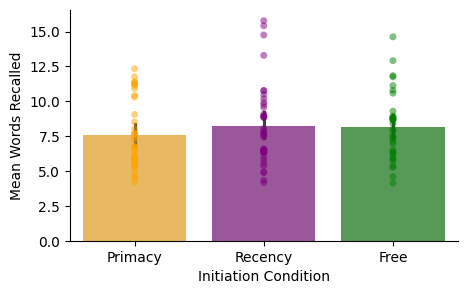

In [230]:
mwr.mwr_plot(mwr_df, path=f'figures/8a_mwr_by_condition.pdf')

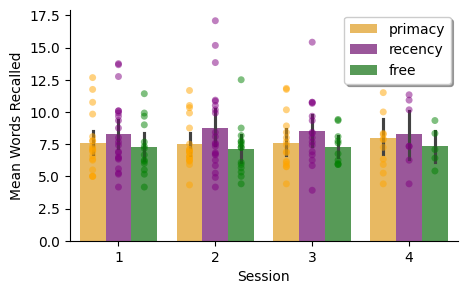

In [1441]:
mwr.mwr_plot_by_session(mwr_df, path=f'figures/8b_mwr_by_condition_by_session.pdf')

## F9(a-b) R1 Intrusion Probability

In [231]:
r1_intrusion_data = r1_intrusion.r1_intrusion_df(filtered_df)
r1_intrusion_data.head(5)

,prolific_pid,session,initiation_condition,prop_wrong
0,5afeea460437f000017e0c97,1,primacy,0.000000
1,5afeea460437f000017e0c97,2,primacy,0.166667
2,5afeea460437f000017e0c97,3,primacy,0.000000
3,5afeea460437f000017e0c97,4,primacy,0.250000
4,5c8ec49f692c610001e14eca,1,primacy,0.000000


In [232]:
summary = (
    r1_intrusion_data
    .groupby("initiation_condition")["prop_wrong"]
    .agg(mean="mean", sd="std")
)

print(summary)

                          mean        sd
initiation_condition                    
free                  0.043981  0.063901
primacy               0.060433  0.083368
recency               0.032828  0.058026


In [233]:
stat_tests.condition_contrast(r1_intrusion_data, ["prop_wrong"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prop_wrong,welch,primacy vs free,39,34,34,1.940051,0.056495,68.446585,0.445020,0.112989
1,prop_wrong,welch,recency vs free,39,34,34,-0.566779,0.572655,70.874924,-0.132094,0.572655
2,prop_wrong,welch,primacy vs recency,39,39,39,2.407780,0.018614,71.979348,0.545255,0.055842


In [234]:
for sess in range(1,5):
    r1_intrusion_prim = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'primacy')]['prop_wrong'].mean()
    print(f'Session {sess} - Primacy: = {r1_intrusion_prim:.3f}')
    r1_intrusion_rec = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'recency')]['prop_wrong'].mean()
    print(f'Session {sess} - Recency: = {r1_intrusion_rec:.3f}')

Session 1 - Primacy: = 0.045
Session 1 - Recency: = 0.034
Session 2 - Primacy: = 0.079
Session 2 - Recency: = 0.028
Session 3 - Primacy: = 0.060
Session 3 - Recency: = 0.042
Session 4 - Primacy: = 0.056
Session 4 - Recency: = 0.025


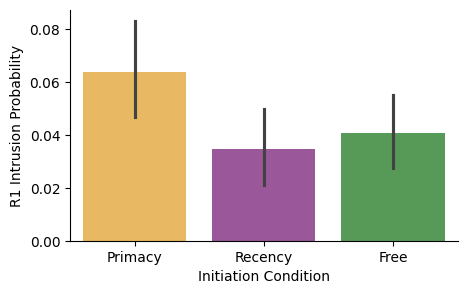

In [235]:
r1_intrusion.r1_intrusion_overall(r1_intrusion_data, path=f'figures/9a_r1_intrusion_overall.pdf')

## F9(c) R1 Response Time

In [236]:
rt_init_df = rt_init.rt_init_df(filtered_df)
rt_init_df.head(5)

,prolific_pid,session,initiation_condition,rt_initial
0,5afeea460437f000017e0c97,1,primacy,1543.383333
1,5afeea460437f000017e0c97,2,primacy,7568.622222
2,5afeea460437f000017e0c97,3,primacy,1733.908333
3,5afeea460437f000017e0c97,4,primacy,290.000000
4,5c8ec49f692c610001e14eca,1,primacy,988.775000


In [237]:
rt_init_df.groupby("initiation_condition")["rt_initial"].agg(mean="mean", sd="std")

,mean,sd
initiation_condition,,
free,1558.249256,1496.444334
primacy,2494.457994,1886.754513
recency,1384.782293,1340.446928


In [238]:
stat_tests.condition_contrast(rt_init_df, ["rt_initial"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,rt_initial,welch,primacy vs free,39,34,34,3.284769,0.001589,70.798104,0.760583,0.003178
1,rt_initial,welch,recency vs free,39,34,34,-0.240441,0.810682,70.970164,-0.055955,0.810682
2,rt_initial,welch,primacy vs recency,39,39,39,3.437368,0.000958,75.584082,0.778410,0.002875


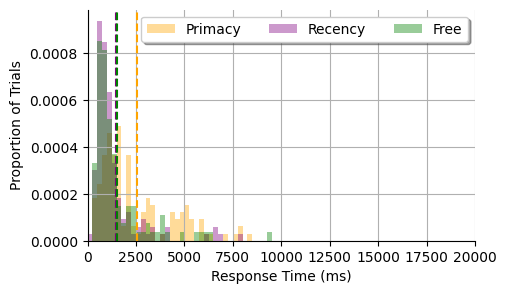

In [239]:
rt_init_plot = rt_init.rt_init_plot(rt_init_df, path=f'figures/9b_rt_init.pdf')

## F10(A-B) PLIs and ELIs

In [240]:
plieli_df = pli_eli.intrusion_rates(filtered_df)
plieli_df.head(10)

,prolific_pid,session,initiation_condition,eli,pli
0,5afeea460437f000017e0c97,1,primacy,1.250000,0.125000
1,5afeea460437f000017e0c97,2,primacy,1.500000,0.000000
2,5afeea460437f000017e0c97,3,primacy,0.583333,0.250000
3,5afeea460437f000017e0c97,4,primacy,1.000000,0.166667
4,5c8ec49f692c610001e14eca,1,primacy,0.250000,0.000000
5,5c8ec49f692c610001e14eca,2,primacy,0.333333,0.125000
6,5c8ec49f692c610001e14eca,3,primacy,0.083333,0.000000
7,5c8ec49f692c610001e14eca,4,primacy,0.250000,0.000000
8,5cc8a32f7639bd0001ccce85,1,recency,43.250000,0.125000
9,5cc8a32f7639bd0001ccce85,2,recency,36.727273,0.000000


In [241]:
plieli_recency = plieli_df[plieli_df['initiation_condition']=='recency']
plieli_recency_eli = plieli_recency['eli'].tolist()
print(f"Recency ELI: {np.mean(plieli_recency_eli)}")
plieli_recency_pli = plieli_recency['pli'].tolist()
print(f"Recency PLI: {np.mean(plieli_recency_pli)}")

plieli_primacy = plieli_df[plieli_df['initiation_condition']=='primacy']
plieli_primacy_eli = plieli_primacy['eli'].tolist()
print(f"Primacy ELI: {np.mean(plieli_primacy_eli)}")
plieli_primacy_pli = plieli_primacy['pli'].tolist()
print(f"Primacy PLI: {np.mean(plieli_primacy_pli)}")


Recency ELI: 1.6305249464340374
Recency PLI: 0.3299963924963925
Primacy ELI: 0.5473965389995924
Primacy PLI: 0.1755270810614322


In [242]:
stat_tests.condition_contrast(plieli_df, ['pli','eli'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,pli,welch,primacy vs free,39,34,34,-1.779797,0.081261,49.397085,-0.433656,0.487566
1,pli,welch,recency vs free,39,34,34,-0.000626,0.999502,69.570376,-0.000144,1.000000
2,pli,welch,primacy vs recency,39,39,39,-1.486975,0.143253,50.385557,-0.336733,0.578063
3,eli,welch,primacy vs free,39,34,34,-1.613543,0.115613,34.981731,-0.404012,0.578063
4,eli,welch,recency vs free,39,34,34,0.563692,0.575268,54.685164,0.126368,1.000000
5,eli,welch,primacy vs recency,39,39,39,-1.421364,0.163252,38.542853,-0.321876,0.578063


In [245]:
import importlib
importlib.reload(pli_eli)

<module 'analyses.pli_eli' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\pli_eli.py'>

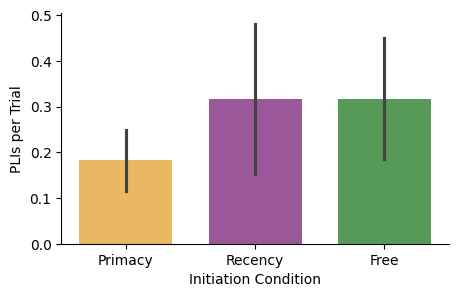

In [246]:
pli_eli.pli_plot_overall(plieli_df, path=f'figures/10a_pli.pdf')

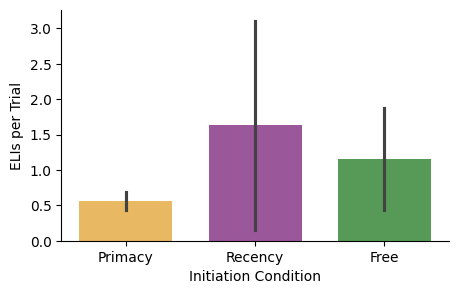

In [247]:
pli_eli.eli_plot_overall(plieli_df, path=f'figures/10b_eli.pdf')

In [1457]:
for sess in range(1,5):
    plieli_sess = plieli_df[plieli_df['session']==sess]
    print(f'Session {sess}')
    print(stat_tests.condition_contrast(plieli_sess, ['pli','eli'], paired=False))

Session 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   19   14  14 -2.046151  0.059914   
1     pli  welch     recency vs free   21   14  14  0.556948  0.581854   
2     pli  welch  primacy vs recency   19   21  19 -3.214490  0.003959   
3     eli  welch     primacy vs free   19   14  14 -1.530361  0.149381   
4     eli  welch     recency vs free   21   14  14 -0.782792  0.444226   
5     eli  welch  primacy vs recency   19   21  19 -1.623980  0.118264   

         dof   cohen_d  p_val_holm  
0  14.062840 -0.830315    0.299569  
1  28.881316  0.190412    0.888452  
2  22.219255 -0.971679    0.023754  
3  13.287807 -0.628582    0.473056  
4  17.479835 -0.305500    0.888452  
5  22.572292 -0.491267    0.473056  
Session 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   19   14  14 -1.045045  0.306226   
1     pli  welch     recency vs free   21   14  14  0.

## F10(C): Final IRTs

In [248]:
irt_final_df = irt.irt_final_df(filtered_df, n_final=4)
irt_final_df.head(5)

,prolific_pid,session,initiation_condition,relative_output_position,irt
0,5afeea460437f000017e0c97,1,primacy,-4.0,1043.071429
1,5afeea460437f000017e0c97,1,primacy,-3.0,2548.555556
2,5afeea460437f000017e0c97,1,primacy,-2.0,2246.583333
3,5afeea460437f000017e0c97,1,primacy,-1.0,5477.466667
4,5afeea460437f000017e0c97,1,primacy,0.0,16097.891667


In [249]:
for pos in range(0,5):
    print(f'Position -{pos}')
    print(stat_tests.condition_contrast(irt_final_df[irt_final_df['relative_output_position']==-1*pos], ['irt'], paired=False))

Position -0
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   39   34  34  0.315800  0.753083   
1     irt  welch     recency vs free   39   34  34  1.781669  0.079080   
2     irt  welch  primacy vs recency   39   39  39 -1.459224  0.148638   

         dof   cohen_d  p_val_holm  
0  70.842343  0.073627    0.753083  
1  70.993208  0.413768    0.237240  
2  75.754556 -0.330449    0.297276  
Position -1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   39   34  34 -0.162432  0.871428   
1     irt  welch     recency vs free   39   34  34  2.064182  0.042682   
2     irt  welch  primacy vs recency   39   39  39 -2.186800  0.031882   

         dof   cohen_d  p_val_holm  
0  70.887730 -0.037851    0.871428  
1  70.503713  0.476973    0.095645  
2  74.849554 -0.495213    0.095645  
Position -2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \


In [250]:
summary = (
    irt_final_df
    .groupby(["initiation_condition", "relative_output_position"])["irt"]
    .agg(mean="mean", sd="std")
    .reset_index()
)

print(summary)

   initiation_condition  relative_output_position         mean           sd
0                  free                      -4.0  2650.608721  1431.187029
1                  free                      -3.0  2768.745350  1296.465807
2                  free                      -2.0  3191.793192  1615.455465
3                  free                      -1.0  4328.774603  2400.571430
4                  free                       0.0  6297.365730  3597.927040
5               primacy                      -4.0  2582.238547  1468.031342
6               primacy                      -3.0  2994.832575  1734.106851
7               primacy                      -2.0  3274.994002  1817.646150
8               primacy                      -1.0  4332.757750  2614.935027
9               primacy                       0.0  6934.368035  4251.519519
10              recency                      -4.0  3180.308953  1721.020258
11              recency                      -3.0  3622.167010  1852.237653
12          

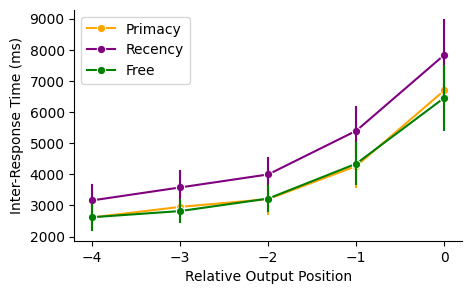

In [251]:
irt.irt_final_plot(irt_final_df, 5, path=f'figures/10c_irt_final.pdf')

In [252]:
irt_tot_df = irt.irt_tot_df(filtered_df)
irt_tot_df.head(5)

,prolific_pid,session,initiation_condition,ncr,ncr_bin,total_irt,irt_h1,irt_h2,irt_delta
0,5afeea460437f000017e0c97,1,primacy,5,2,5977.45,1177.6,3765.45,2587.85
1,5afeea460437f000017e0c97,1,primacy,6,3,13072.80,4136.4,8936.40,4800.00
2,5afeea460437f000017e0c97,1,primacy,9,4,16456.90,4383.1,9333.20,4950.10
3,5afeea460437f000017e0c97,1,primacy,11,5,60099.00,8690.1,46827.10,38137.00
4,5afeea460437f000017e0c97,2,primacy,4,2,25046.40,1730.3,23316.10,21585.80


In [253]:
for bin in range(1, 11):
    print(f'NCR Bin {bin}')
    print(stat_tests.condition_contrast(irt_tot_df[irt_tot_df['ncr_bin']==bin], ['irt_delta'], paired=False))

NCR Bin 1
     measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free   19   12  12 -2.530055  0.025385   
1  irt_delta  welch     recency vs free   17   12  12 -1.284054  0.214090   
2  irt_delta  welch  primacy vs recency   19   17  17 -1.577532  0.128875   

         dof   cohen_d  p_val_holm  
0  12.782778 -1.121562    0.076154  
1  19.606954 -0.507681    0.257749  
2  22.109900 -0.546374    0.257749  
NCR Bin 2
     measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free   29   24  24 -0.153654  0.878492   
1  irt_delta  welch     recency vs free   30   24  24  0.175301  0.861537   
2  irt_delta  welch  primacy vs recency   29   30  29 -0.299158  0.765913   

         dof   cohen_d  p_val_holm  
0  50.750150 -0.041362         1.0  
1  51.025694  0.046123         1.0  
2  56.714106 -0.077764         1.0  
NCR Bin 3
     measure   test            contrast  n_1  n_2   n   

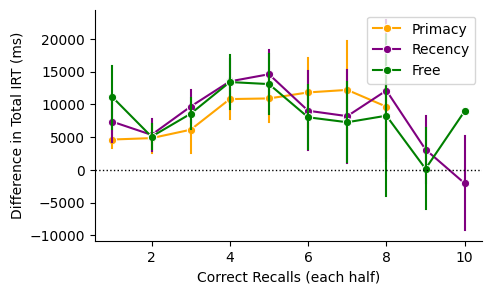

In [254]:
irt.irt_tot_plot(irt_tot_df, path=f'figures/10e_irt_total.pdf')

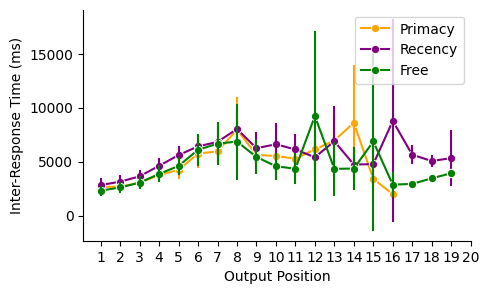

In [255]:
irt_first_df = irt.irt_first_df(filtered_df, n_first=20)
irt.irt_first_plot(irt_first_df, n_first=20, path=f'figures/10d_irt_first.pdf')

In [1466]:
for pos in range(1, 21):
    print(f'Output Position {pos}')
    print(stat_tests.condition_contrast(irt_first_df[irt_first_df['output_position']==pos], ['irt'], paired=False))

Output Position 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.796563  0.431949   
1     irt  welch     recency vs free   21   14  14  0.713057  0.481377   
2     irt  welch  primacy vs recency   19   21  19  0.123466  0.902404   

         dof   cohen_d  p_val_holm  
0  30.072886  0.274503         1.0  
1  29.695113  0.241603         1.0  
2  37.109730  0.039197         1.0  
Output Position 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.254644  0.801225   
1     irt  welch     recency vs free   21   14  14  0.568959  0.575282   
2     irt  welch  primacy vs recency   19   21  19 -0.404829  0.687945   

         dof   cohen_d  p_val_holm  
0  23.377238  0.093523         1.0  
1  21.491904  0.210474         1.0  
2  36.818433 -0.128684         1.0  
Output Position 3
  measure   test            contrast  n_1  n_2   n    t_

## F11(A-B). Temporal clustering score

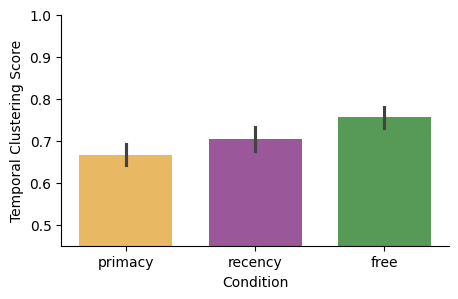

In [256]:
tcl_df = tcl.tcl(filtered_df)
tcl.plot_tcl(tcl_df, path="figures/11a_tcl_overall.pdf")

In [257]:
stat_tests.condition_contrast(tcl_df, ['tcl'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl,welch,primacy vs free,39,34,34,-4.902321,0.000006,70.359353,-1.146753,0.000018
1,tcl,welch,recency vs free,39,34,34,-2.652908,0.009841,70.913070,-0.615044,0.019682
2,tcl,welch,primacy vs recency,39,39,39,-1.948817,0.055071,74.741298,-0.441320,0.055071


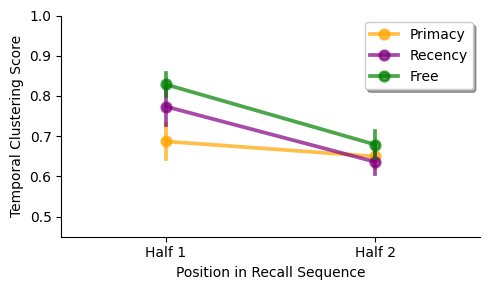

In [258]:
tcl_h_df = tcl.tcl_h(filtered_df)
tcl.plot_tcl_h(tcl_h_df, path="figures/11b_tcl_half.pdf")

In [259]:
stat_tests.condition_contrast(tcl_h_df, ['tcl_h1', 'tcl_h2', 'tcl_delta'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl_h1,welch,primacy vs free,39,34,34,-5.361188,0.000001,62.722894,-1.216091,0.000011
1,tcl_h1,welch,recency vs free,39,34,34,-2.010226,0.048822,61.179068,-0.454879,0.244109
2,tcl_h1,welch,primacy vs recency,39,39,39,-2.676436,0.009115,75.833725,-0.606093,0.054687
3,tcl_h2,welch,primacy vs free,39,34,34,-1.296784,0.199075,68.211724,-0.305610,0.597225
4,tcl_h2,welch,recency vs free,39,34,34,-1.878943,0.064505,68.545588,-0.442404,0.258018
5,tcl_h2,welch,primacy vs recency,39,39,39,0.632014,0.529275,75.986911,0.143123,1.000000
6,tcl_delta,welch,primacy vs free,39,34,34,3.662946,0.000516,62.413880,0.830463,0.004126
7,tcl_delta,welch,recency vs free,39,34,34,0.411392,0.682151,64.411245,0.093582,1.000000
8,tcl_delta,welch,primacy vs recency,39,39,39,2.806357,0.006367,75.713729,0.635515,0.044567


## F11(C) Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


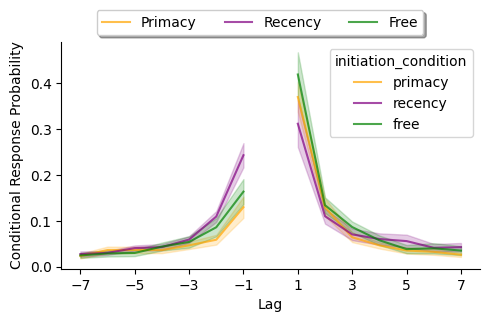

In [260]:
lcrp_df = lcrp.lag_crp(filtered_df)
lcrp.plot_lcrp(lcrp_df, max_lag = 7, path='figures/11c_lcrp.pdf')

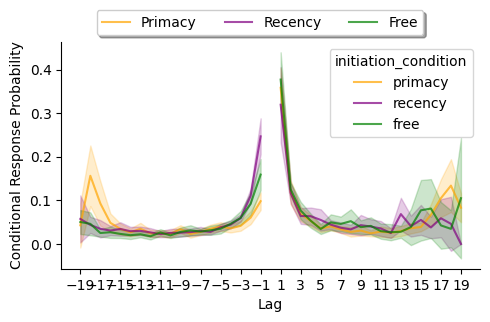

In [1472]:
lcrp.plot_lcrp(lcrp_df, max_lag = 19, path='figures/11e_lcrp_full.pdf')

In [1473]:
fwd_asym_df = lcrp_df.apply(lambda row: lcrp.forward_asymmetry(row, n=1), axis=1)

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,19,14,14,0.943557,0.356483,20.315532,0.356101,0.356483
1,asym,welch,recency vs free,21,14,14,-2.143337,0.039657,32.544825,-0.667745,0.079314
2,asym,welch,primacy vs recency,19,21,19,3.169952,0.003924,25.627541,0.964923,0.011771


In [1474]:
stat_tests.condition_contrast(lcrp_df, ["lp_1", "ln_1"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,lp_1,welch,primacy vs free,19,14,14,-0.478229,6.365984e-01,25.270000,-0.172847,0.892727
1,lp_1,welch,recency vs free,21,14,14,-1.058551,2.975758e-01,32.638686,-0.330525,0.892727
2,lp_1,welch,primacy vs recency,19,21,19,0.778179,4.425583e-01,29.999079,0.238907,0.892727
3,ln_1,welch,primacy vs free,19,14,14,-2.909233,8.376381e-03,21.040890,-1.090614,0.033506
4,ln_1,welch,recency vs free,21,14,14,3.142667,3.537203e-03,32.843578,1.012031,0.017686
5,ln_1,welch,primacy vs recency,19,21,19,-6.329397,6.660326e-07,28.820513,-1.938694,0.000004


In [1475]:
tmp = stat_tests.participant_condition_mean(lcrp_df, ["lp_1", "ln_1"])

tmp.groupby("initiation_condition")[["lp_1", "ln_1"]].agg(["mean", "sem", "count"])

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,19,14,14,0.943557,0.356483,20.315532,0.356101,0.356483
1,asym,welch,recency vs free,21,14,14,-2.143337,0.039657,32.544825,-0.667745,0.079314
2,asym,welch,primacy vs recency,19,21,19,3.169952,0.003924,25.627541,0.964923,0.011771


## F11(d) Semantic Clustering

In [261]:
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')

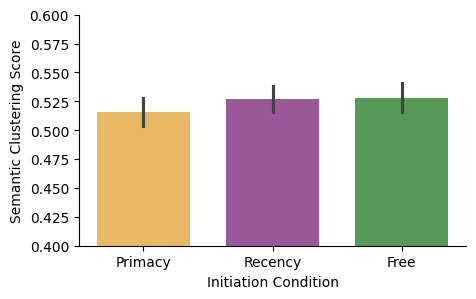

In [262]:
scl_df = scl.scl(filtered_df, wordpool, w2v_scores)
scl.plot_scl(scl_df, path="figures/11d_scl_by_condition.pdf")

In [263]:
stat_tests.one_sample(scl_df, ["scl"], popmean=0.5)

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,scl,one_sample,39,2.615092,0.012722,38,0.41875,0.012722
1,recency,scl,one_sample,39,4.730085,0.000031,38,0.75742,0.000092
2,free,scl,one_sample,34,4.491350,0.000082,33,0.77026,0.000164


In [1479]:
# 3) stats
stat_tests.condition_contrast(scl_df, ["scl"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,scl,welch,primacy vs free,19,14,14,-0.847458,0.407013,19.515863,-0.322292,1.0
1,scl,welch,recency vs free,21,14,14,-0.322216,0.750516,20.727345,-0.120296,1.0
2,scl,welch,primacy vs recency,19,21,19,-0.782605,0.438714,37.966177,-0.246120,1.0
